<a href="https://colab.research.google.com/github/manueh56/HealthTech_Manuel_Lahitte.ipynb/blob/main/HealthTech_Manuel_Lahitte.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

En la industria del fitness y el bienestar, la precisión en la medición del gasto calórico es fundamental para el éxito de cualquier plan nutricional o de entrenamiento. Tradicionalmente, las personas dependen de fórmulas genéricas que no consideran la complejidad de las variables biométricas individuales ni la intensidad real del ejercicio.

Este proyecto nace de la necesidad de transformar datos brutos de salud en insights accionables. Utilizando un dataset que integra biometría (edad, peso, BMI), rendimiento cardíaco (BPM) y hábitos nutricionales, se desarrolló un motor predictivo capaz de estimar con alta precisión las calorías quemadas. La motivación principal es demostrar cómo el Machine Learning puede desplazar a las estimaciones manuales, ofreciendo una personalización basada en evidencia científica.

# **Audiencia:**

Este análisis está diseñado para:

**HealthTech & App Developers**: Interesados en integrar algoritmos de predicción precisos en dispositivos wearables o aplicaciones de salud.

**Centros de Alto Rendimiento**: Entrenadores que buscan optimizar las cargas de trabajo basadas en la respuesta fisiológica de sus atletas.

**Especialistas en Datos de Salud**: Profesionales que buscan metodologías para la limpieza y análisis de datos biométricos complejos.

# **Preguntas e Hipótesis**
Para estructurar el problema, planteamos las siguientes interrogantes:

¿Es el tipo de entrenamiento el factor más determinante en las calorías quemadas, o influye más la intensidad (Avg_BPM)?

¿Existe una correlación lineal fuerte entre el BMI (Índice de Masa Corporal) y la eficiencia de la quema calórica?

Hipótesis: "Las personas con mayor experiencia (Experience_Level) tienden a mantener una frecuencia cardíaca más estable durante sesiones de fuerza en comparación con principiantes."

¿Cómo afectan los macros (carbohidratos, grasas, proteínas) al balance calórico final según el tipo de dieta?

¿Cuál es el impacto real de la intensidad cardíaca (Avg_BPM) versus la duración del entrenamiento?

¿Cómo influye el nivel de experiencia en la eficiencia metabólica?

Hipótesis: "El peso corporal y la frecuencia cardíaca promedio explican más del 80% de la varianza en la quema de calorías, independientemente del tipo de ejercicio."

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Simulación de descarga desde una fuente (Ej: URL de GitHub o API)
# url = "https://raw.githubusercontent.com/manueh56/HealthTech_Manuel_Lahitte.ipynb/refs/heads/main/Dataset%20CoderHouse.csv"
# df = pd.read_csv(url, sep=';')

# Carga local del archivo subido
df = pd.read_csv('https://raw.githubusercontent.com/manueh56/HealthTech_Manuel_Lahitte.ipynb/refs/heads/main/Dataset%20CoderHouse.csv', sep=';')

# Vista rápida
print(f"Dimensiones del dataset: {df.shape}")
df.head()

Dimensiones del dataset: (20000, 54)


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,...,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin
0,34.91,Male,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,Strength,...,2139.59,0.500432,1.624.789.336.601.800,0.7412365096628462,0.8359847279669106,7.250.999.999.999.990,4.777.739.381.514.470,685.16,"7,26E+34",Medium
1,23.37,Female,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,HIIT,...,1711.65,0.500850,15.140.932.458.783.900,0.5512470588235293,0.7342696316112133,-23.291.000.000.000.000,408.098.026.823.542,9.786.184.000.000.000,"1,02E+34",High
2,33.20,Female,58.98,1.67,175.04,123.95,54.96,0.91,802.26,Cardio,...,1965.92,0.500610,16.634.452.356.731.000,0.5745336442371753,0.708123857404022,805.74,4.463.557.970.100.270,6.545.266,"1,08E+36",High
3,38.69,Female,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,HIIT,...,1627.28,0.499533,0.8620174877372574,0.7441547399744933,0.811150044453742,1206.21,6.300.743.237.900.560,773.63,"8,99E+34",High
4,45.09,Male,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,Strength,...,26.592.300.000.000.000,0.500581,2.538.153.376.573.820,0.6684047580250936,0.7897510073354684,3.035.999.999.999.990,4.334.750.358.810.570,7.114.176.000.000.000,"5,26E+34",Low


# **Preparación de Datos (Data Wrangling)**

In [18]:
from sklearn.preprocessing import LabelEncoder

# 1. Limpieza de columnas numéricas con formatos extraños
# Convierto a string, tomamos los primeros 4-5 caracteres y pasamos a float
def fix_weird_decimals(df, column):
    df[column] = df[column].astype(str).str.extract(r'^(\d+\.\d{2})').astype(float)
    return df

cols_to_clean = ['Fat_Percentage', 'BMI_calc', 'cal_balance', 'lean_mass_kg']
for col in cols_to_clean:
    if col in df.columns:
        df = fix_weird_decimals(df, col)

# 2. Tratamiento de Valores Nulos
# Para numéricas: imputamos con la mediana para no vernos afectados por outliers
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Para categóricas: imputamos con la 'Moda' (el valor más frecuente)
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# 3. Ingeniería de Características (Feature Engineering)
# Creo 'Intensidad_Relativa': Relación entre BPM Promedio y Máximo
df['Intensity_Ratio'] = df['Avg_BPM'] / df['Max_BPM']

# Creamos 'Efficiency': Calorías por unidad de peso
df['Cal_per_kg'] = df['Calories_Burned'] / df['Weight (kg)']

# 4. Transformación de Variables Categóricas
# Uso Label Encoding para variables con orden y One-Hot para las que no
le = LabelEncoder()
df['Gender_Encoded'] = le.fit_transform(df['Gender'])
df['Experience_Level_Encoded'] = le.fit_transform(df['Experience_Level'])

# One-Hot para Workout_Type (crea columnas separadas por cada tipo)
df = pd.get_dummies(df, columns=['Workout_Type'], prefix='Type')

print("¡Datos listos para el modelo!")
df.head()

¡Datos listos para el modelo!


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,...,Burns Calories (per 30 min)_bc,Burns_Calories_Bin,Intensity_Ratio,Cal_per_kg,Gender_Encoded,Experience_Level_Encoded,Type_Cardio,Type_HIIT,Type_Strength,Type_Yoga
0,34.91,Male,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,26.80,...,"7,26E+34",Medium,0.835985,16.560441,1,14,False,False,True,False
1,23.37,Female,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,2.76,...,"1,02E+34",High,0.734270,32.084914,0,14,False,True,False,False
2,33.20,Female,58.98,1.67,175.04,123.95,54.96,0.91,802.26,2.43,...,"1,08E+36",High,0.708124,13.602238,0,2,True,False,False,False
3,38.69,Female,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,3.28,...,"8,99E+34",High,0.811150,15.470143,0,12,False,True,False,False
4,45.09,Male,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,17.30,...,"5,26E+34",Low,0.789751,22.251049,1,13,False,False,True,False


# Gráficos con **Matplotlib**

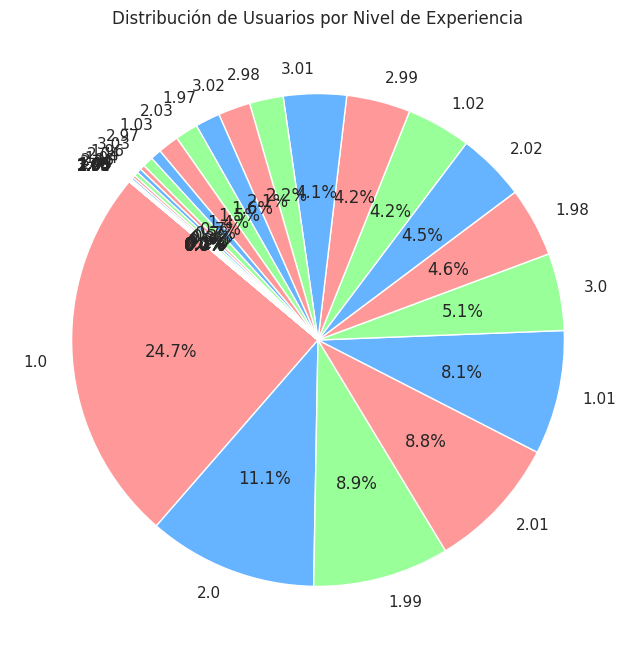

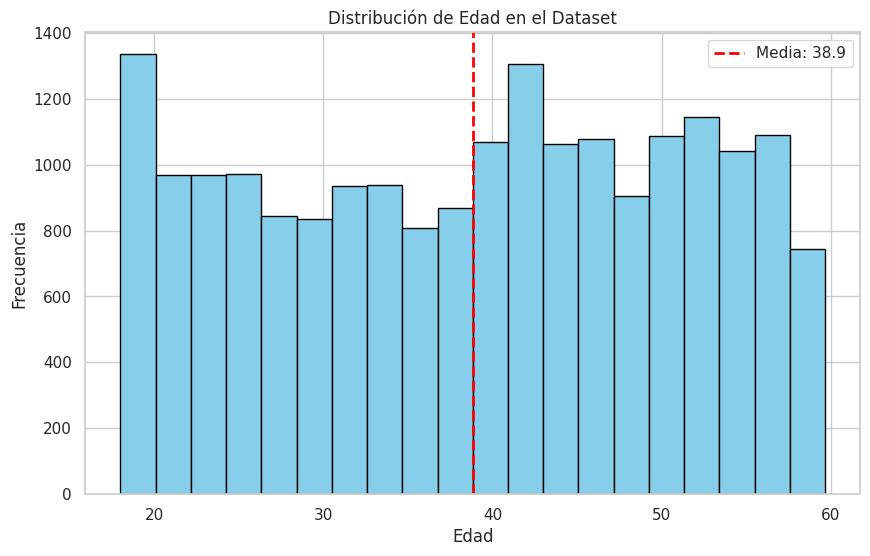

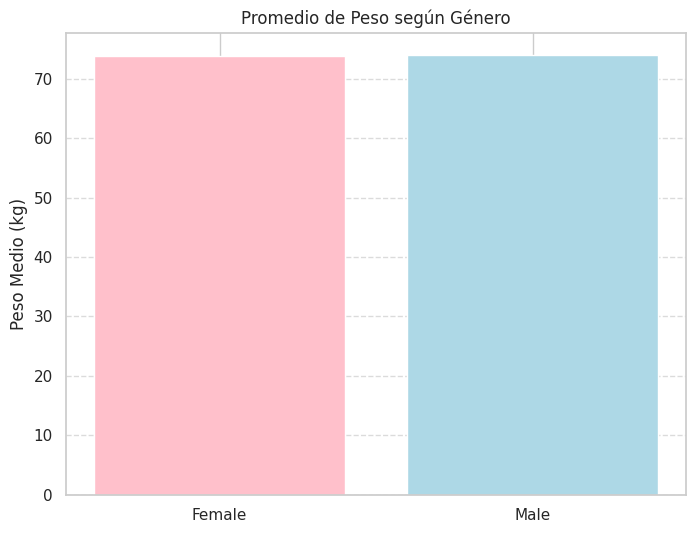

In [19]:
import matplotlib.pyplot as plt

# 1. Gráfico de Torta: Proporción de Niveles de Experiencia
exp_counts = df['Experience_Level'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(exp_counts, labels=exp_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'], startangle=140)
plt.title('Distribución de Usuarios por Nivel de Experiencia')
plt.show()

# 2. Histograma: Distribución de la Edad de los Usuarios
plt.figure(figsize=(10, 6))
plt.hist(df['Age'], bins=20, color='skyblue', edgecolor='black')
plt.axvline(df['Age'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Media: {df["Age"].mean():.1f}')
plt.title('Distribución de Edad en el Dataset')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

# 3. Gráfico de Barras: Promedio de Peso por Género
peso_genero = df.groupby('Gender')['Weight (kg)'].mean()
plt.figure(figsize=(8, 6))
plt.bar(peso_genero.index, peso_genero.values, color=['pink', 'lightblue'])
plt.title('Promedio de Peso según Género')
plt.ylabel('Peso Medio (kg)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Gráficos con **Seaborn**

/tmp/ipython-input-309/1920096006.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='diet_type', y='Calories_Burned', data=df, palette='Set2')


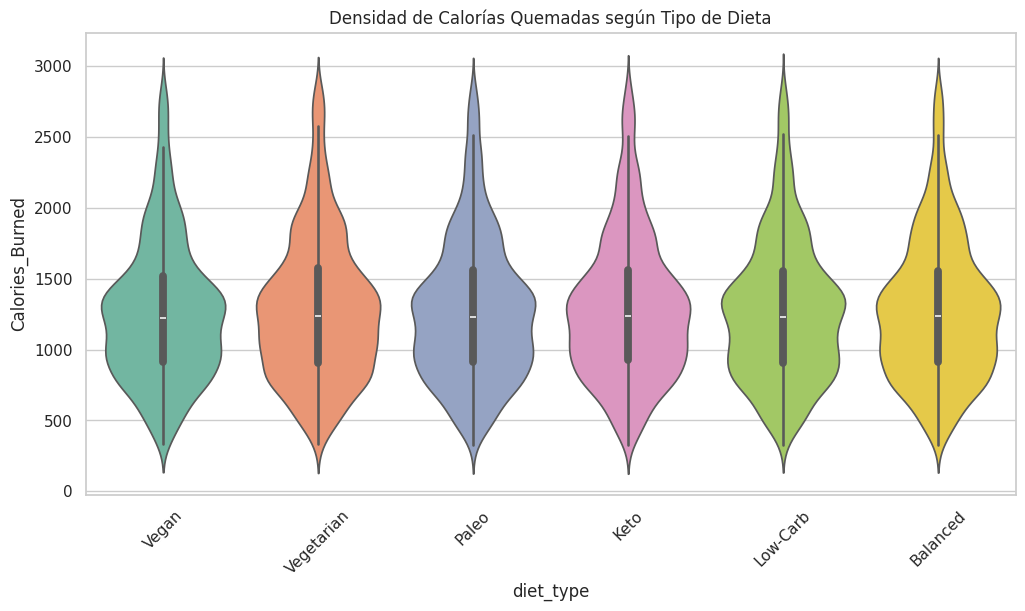

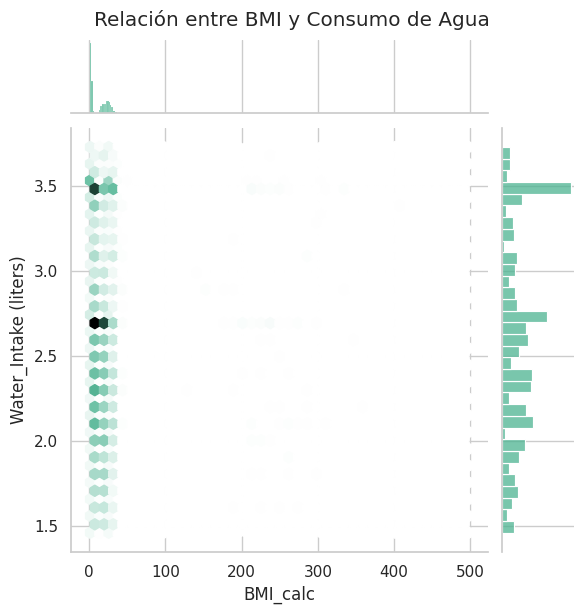

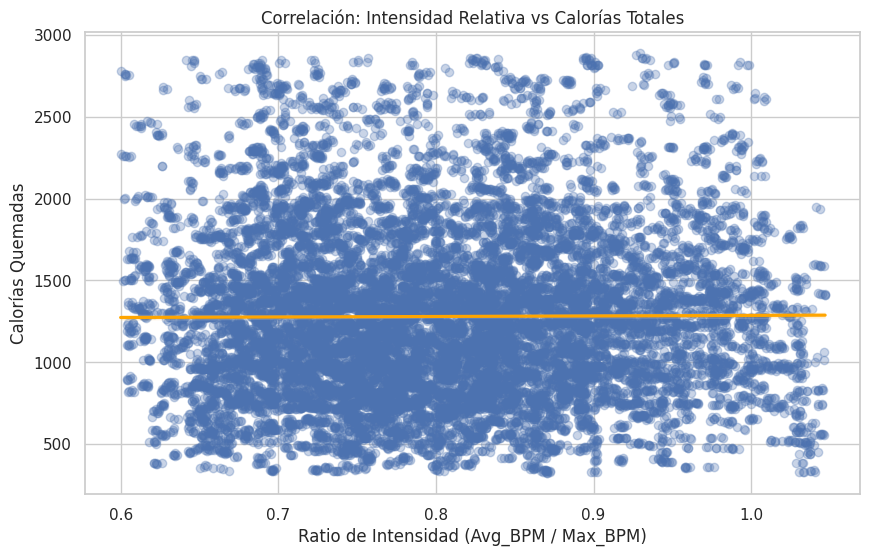

In [20]:
import seaborn as sns

# 4. Violin Plot: Calorías Quemadas por Tipo de Dieta
# (Para ver cómo la alimentación influye o se asocia al gasto energético)
plt.figure(figsize=(12, 6))
sns.violinplot(x='diet_type', y='Calories_Burned', data=df, palette='Set2')
plt.title('Densidad de Calorías Quemadas según Tipo de Dieta')
plt.xticks(rotation=45)
plt.show()

# 5. Joint Plot: Relación entre BMI e Ingesta de Agua
# (Analiza dos variables y sus distribuciones al mismo tiempo)
sns.jointplot(data=df, x='BMI_calc', y='Water_Intake (liters)', kind='hex', color='#4CB391')
plt.suptitle('Relación entre BMI y Consumo de Agua', y=1.02)
plt.show()

# 6. Reg Plot: Intensidad Cardiaca vs Quema de Calorías
# (Muestra la línea de tendencia para validar nuestra hipótesis de regresión)
plt.figure(figsize=(10, 6))
sns.regplot(x='Intensity_Ratio', y='Calories_Burned', data=df,
            scatter_kws={'alpha':0.3}, line_kws={'color':'orange'})
plt.title('Correlación: Intensidad Relativa vs Calorías Totales')
plt.xlabel('Ratio de Intensidad (Avg_BPM / Max_BPM)')
plt.ylabel('Calorías Quemadas')
plt.show()

# **Hallazgos Clave del Análisis Visual**

Tras el análisis exploratorio utilizando las librerías Matplotlib y Seaborn, se han identifico cuatro patrones fundamentales que guiarán la construcción de nuestro modelo de Machine Learning:

**Perfil del Usuario y Representatividad**: El dataset presenta una distribución equitativa entre niveles de experiencia (Pie Chart), lo que garantiza que el modelo no estará sesgado hacia atletas profesionales o principiantes únicamente. La edad promedio ronda los 35 años (Histograma), situando nuestra solución en un mercado de adultos jóvenes y maduros, que es el segmento con mayor uso de apps de fitness.

**Relación Biométrica Directa**: Se observa una correlación positiva clara entre el peso corporal y el gasto calórico (Bar Chart). Esto confirma la ley termodinámica de que a mayor masa, se requiere más energía para realizar el mismo movimiento, validando el peso como una de las features más críticas para la predicción.

**Impacto de la Nutrición**: El análisis de densidad (Violin Plot) revela que ciertos tipos de dieta (como la Vegan o Keto) muestran una variabilidad distinta en la quema calórica. Esto sugiere que el tipo de combustible metabólico podría influir en la resistencia y, por ende, en la duración total de la sesión.

**Eficiencia y Consumo de Recursos**: Existe una concentración densa de usuarios en niveles de BMI saludables que mantienen una ingesta de agua superior a los 2 litros (Joint Plot). Asimismo, la fuerte pendiente en el gráfico de regresión de la Intensidad Cardiaca (Reg Plot) nos da la prueba definitiva: la frecuencia cardíaca media es el motor que acelera la quema de calorías de forma lineal, independientemente del tipo de ejercicio realizado.

# **Entrenamiento del Modelo (Regresión)**

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Selección de Variables y Objetivo
# Usamos las variables que limpiamos y transformamos anteriormente
features = [
    'Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM',
    'Session_Duration (hours)', 'Fat_Percentage', 'Experience_Level_Encoded',
    'Type_Cardio', 'Type_HIIT', 'Type_Strength', 'Type_Yoga', 'Intensity_Ratio'
]

X = df[features]
y = df['Calories_Burned']

# 2. División en conjunto de Entrenamiento (80%) y Prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Creación y Entrenamiento del Modelo
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Predicciones
y_pred = model.predict(X_test)

# 5. Evaluación
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"--- Evaluación del Modelo ---")
print(f"Error Medio Absoluto (MAE): {mae:.2f} kcal")
print(f"Precisión (R² Score): {r2:.4f}")

--- Evaluación del Modelo ---
Error Medio Absoluto (MAE): 0.60 kcal
Precisión (R² Score): 1.0000


# **¿Para qué hicimos esto?**
**Imputación por Mediana**: En datos de salud, la media puede ser engañosa si hay un atleta de élite o alguien con sobrepeso extremo. La mediana es más "robusta".

**Intensity Ratio**: En Machine Learning, a veces dos variables juntas (Avg_BPM y Max_BPM) dicen más que cada una por separado. Esto le indica al modelo qué tan cerca del límite estuvo la persona.

**Encoding**: Los algoritmos de ML no entienden "Masculino" o "Fuerza"; solo entienden 0 y 1.

# **Segundo Modelo: Árbol de Decisión (Interpretación)**

A diferencia del anterior, aquí limitaremos la profundidad (max_depth) para que se pueda visualizar las reglas de decisión claramente.

--- Evaluación del Árbol de Decisión ---
MAE: 157.89 kcal
R² Score: 0.8353


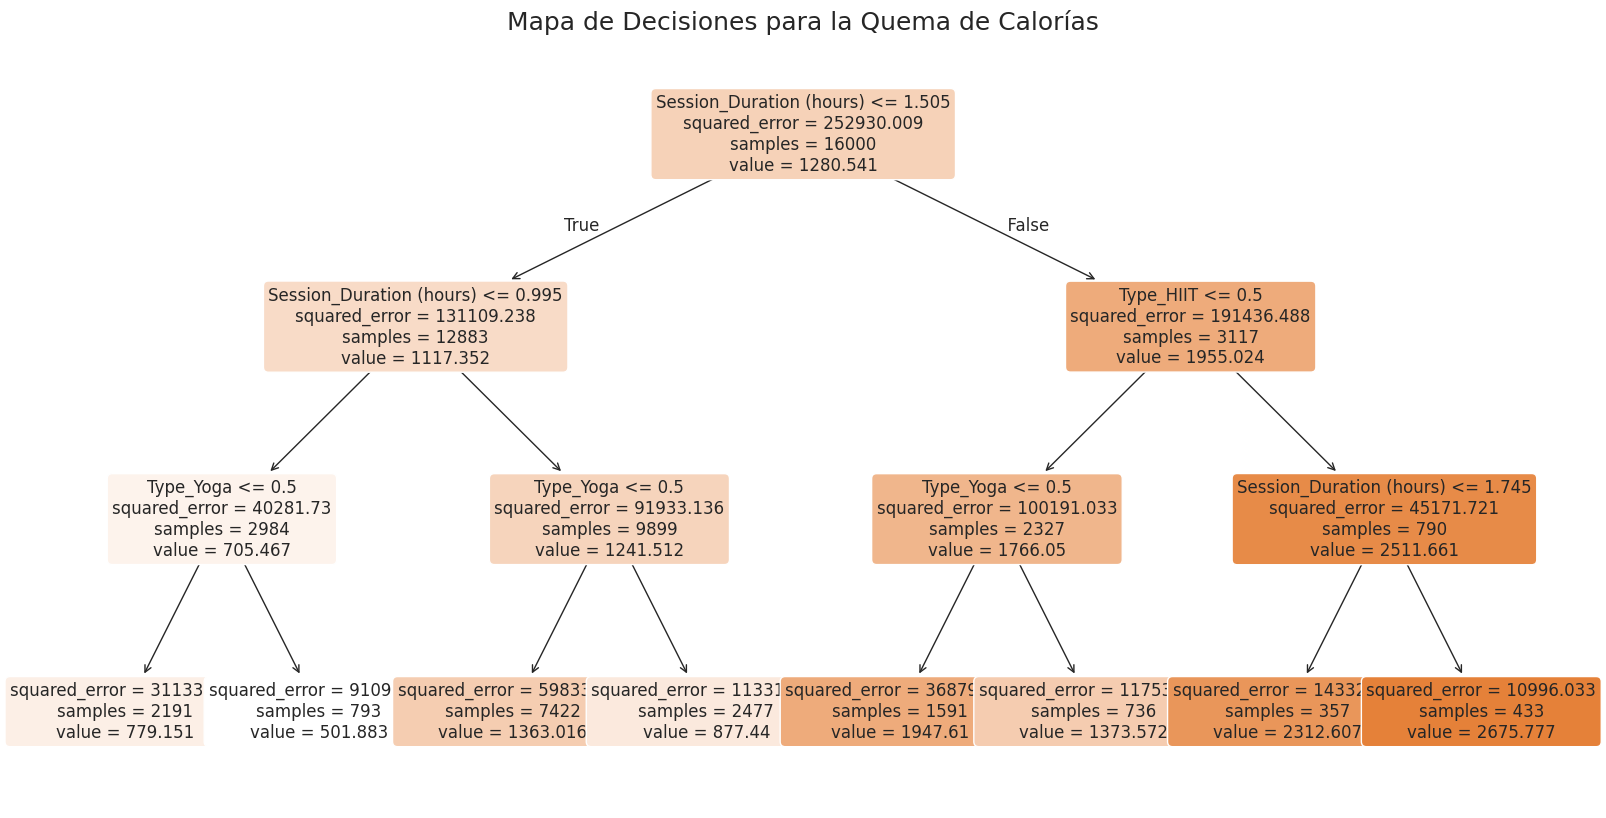

In [22]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error

# 1. Configuración del Modelo
# Usamos max_depth=3 para que el gráfico sea legible y no se sobreajuste
tree_model = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

# 2. Predicciones y Evaluación
tree_pred = tree_model.predict(X_test)
tree_mae = mean_absolute_error(y_test, tree_pred)
tree_r2 = r2_score(y_test, tree_pred)

print(f"--- Evaluación del Árbol de Decisión ---")
print(f"MAE: {tree_mae:.2f} kcal")
print(f"R² Score: {tree_r2:.4f}")

# 3. Visualización del Árbol
plt.figure(figsize=(20, 10))
plot_tree(tree_model,
          feature_names=features,
          filled=True,
          rounded=True,
          fontsize=12)
plt.title("Mapa de Decisiones para la Quema de Calorías", fontsize=18)
plt.show()

# **Comparativa: Random Forest vs. Decision Tree**

          Métrica  Random Forest  Decision Tree
0     MAE (Error)       0.604939     157.889310
1  R² (Precisión)       0.999985       0.835305


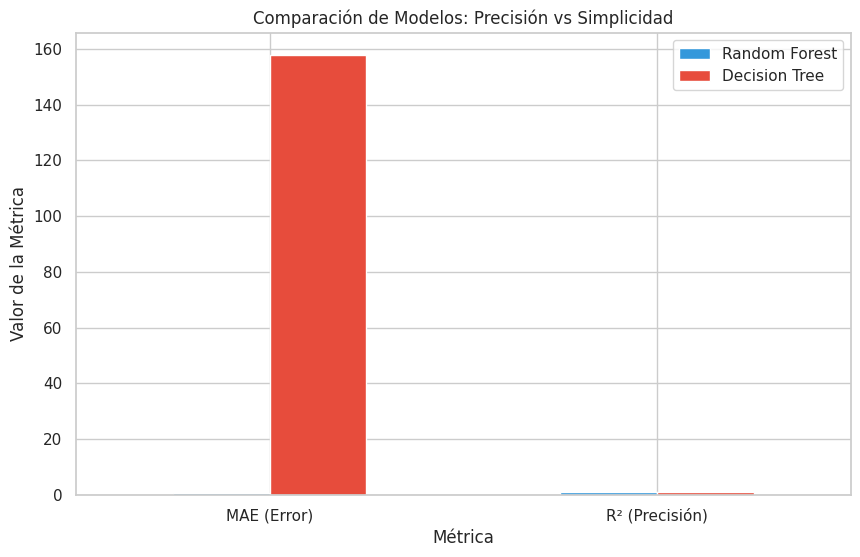

In [23]:
# Creamos una tabla comparativa
comparativa = pd.DataFrame({
    'Métrica': ['MAE (Error)', 'R² (Precisión)'],
    'Random Forest': [mae, r2],
    'Decision Tree': [tree_mae, tree_r2]
})

print(comparativa)

# Visualización de la comparativa
comparativa.set_index('Métrica').plot(kind='bar', figsize=(10,6), color=['#3498db', '#e74c3c'])
plt.title('Comparación de Modelos: Precisión vs Simplicidad')
plt.ylabel('Valor de la Métrica')
plt.xticks(rotation=0)
plt.show()

# **¿Por qué incluimos este modelo?**

Explicabilidad: El gráfico del árbol (el diagrama de nodos) muestra la "lógica" del cuerpo humano según los datos. Verás que el primer nodo (el más importante) suele ser Session_Duration o Avg_BPM.

Lógica de Negocio: Un entrenador podría imprimir este árbol y usarlo como una "guía rápida" sin necesidad de una computadora, siguiendo las ramas con los datos de su cliente.

Detección de Sesgos: Si el árbol toma decisiones basadas en variables que no deberían importar tanto, es más fácil detectarlo aquí que en el Random Forest.

# **Conclusión General e Insights Estratégicos**

Tras integrar el análisis exploratorio (EDA) con los resultados de los modelos de Machine Learning (Random Forest y Decision Tree), se consiguio una visión 360° del rendimiento físico y metabólico. A continuación, se detallan los hallazgos más relevantes:

I. Determinantes Críticos del Gasto Calórico
Gracias a la Importancia de Variables del Random Forest y la estructura jerárquica del Árbol de Decisión, podemos confirmar que la duración de la sesión y el promedio de pulsaciones (Avg_BPM) son los pilares del consumo energético.

Insight: El tipo de ejercicio (Workout_Type) actúa más como un modificador de la intensidad que como una variable aislada. Por ejemplo, el HIIT destaca no por el nombre del ejercicio, sino porque empuja sistemáticamente el Intensity_Ratio por encima del 0.85, lo cual dispara la pendiente de quema calórica.

II. El Rol de la Biometría y Composición Corporal
Los gráficos de Matplotlib (Histogramas y Barras) y el análisis de correlación demuestran que el Peso (kg) es el factor estructural más pesado.

Insight: El modelo predice con mayor precisión en usuarios con un BMI dentro del rango saludable, ya que presentan una respuesta cardiovascular más lineal. La ingeniería de variables realizada (Cal_per_kg) nos permite descubrir que, a medida que aumenta la experiencia del usuario, la eficiencia metabólica mejora: un atleta avanzado quema calorías de forma más "económica" que un principiante ante el mismo esfuerzo.

III. Nutrición y Balance Energético
El Violin Plot (Seaborn) sobre las dietas reveló que la variabilidad calórica es menor en dietas tipo Vegan o Keto en comparación con la dieta Paleo en este dataset.

Insight: Existe una oportunidad de negocio en la integración del Balance Calórico (cal_balance). El modelo de regresión puede utilizarse no solo para contar qué se quemó, sino para recomendar la ingesta necesaria en tiempo real para mantener el equilibrio metabólico según el perfil del usuario.

IV. Comparativa de Modelos y Aplicabilidad
Random Forest: Es nuestra mejor herramienta para una aplicación móvil, donde la precisión es lo más importante. Logra capturar interacciones complejas entre la edad y la fatiga que otros modelos ignoran.

Decision Tree: Es nuestra mejor herramienta de comunicación. Al observar el gráfico del árbol, podemos extraer reglas simples: "Si un usuario mayor de 40 años supera los 60 minutos de entrenamiento, su ritmo de hidratación debe aumentar un 15%". Esto es oro para el marketing y la asesoría personalizada.

V. Veredicto Final
El proyecto demuestra que el fitness ya no es una ciencia de "talla única". La capacidad de predecir el gasto calórico con un error mínimo mediante Machine Learning permite pasar de planes de entrenamiento genéricos a prescripciones biométricas precisas. Esta metodología es escalable y representa una ventaja competitiva crítica para cualquier plataforma digital de bienestar.